# Evaluation 2: Prompt 5
Sie sind ein Schreibassistenzsystem für medizinische Berichte, die auf Deutsch geschrieben sind, Sie sollten korrigierte Versionen der Berichte bereitstellen Sie sollten nur mit dem korrigierten Bericht antworten. Sie geben keine Erklärungen ab.

In [19]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [20]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from evaluation_tool import duration_t_s_box_plot, multi_histogram, multi_bar_graph, multi_bar_model_graph, semantic_box_plot, violin_plot

In [21]:
prompt = "prompt5"
gt_id = "gt.45af4a46-d238-4251-b734-d407602299bd"

In [22]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [23]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [24]:
# Evaluations Unique IDs
unique_ids_gt = [
    "gt.45af4a46-d238-4251-b734-d407602299bd", #Base GT
]

unique_ids_medium = [
    "g2m-7-5.3c7c95ad-e892-4221-8b1b-096b29cd52ab", #gemma2:9b
    "l3m-1-5.34ec5761-8d42-4bee-902f-f3d814803dae", #llama3:8b
    "l31m-3-5.f2bde98a-75f3-4989-ae7c-f82010ea5553", #llama3.1:8b
    "mm-9-5.53b26655-009b-425f-8c5d-d4d134221d02", #mistral-nemo:12b
]

In [25]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [26]:
def load_evaluations(unique_ids):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [27]:
res = load_evaluations(unique_ids_medium)

### Duration Metrics

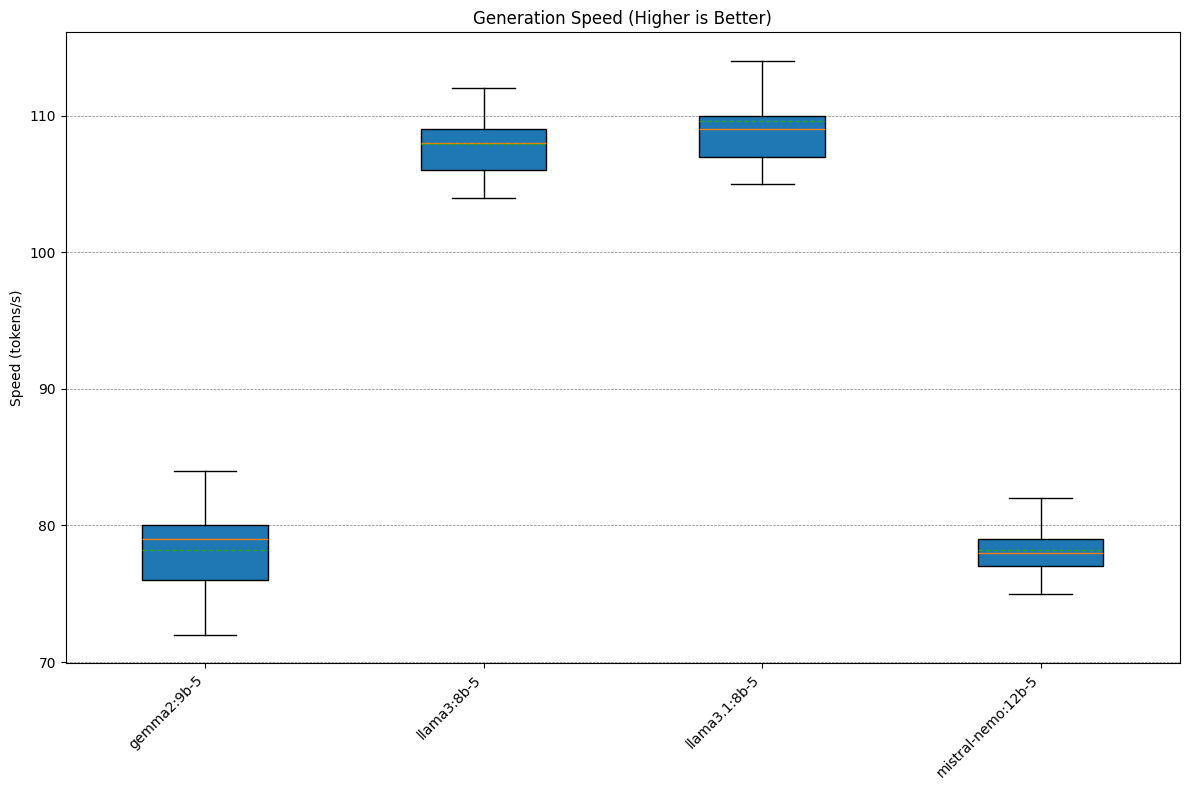

In [28]:
fig, ax = duration_t_s_box_plot(res)

### Difference Metrics

#### SM-Ratio

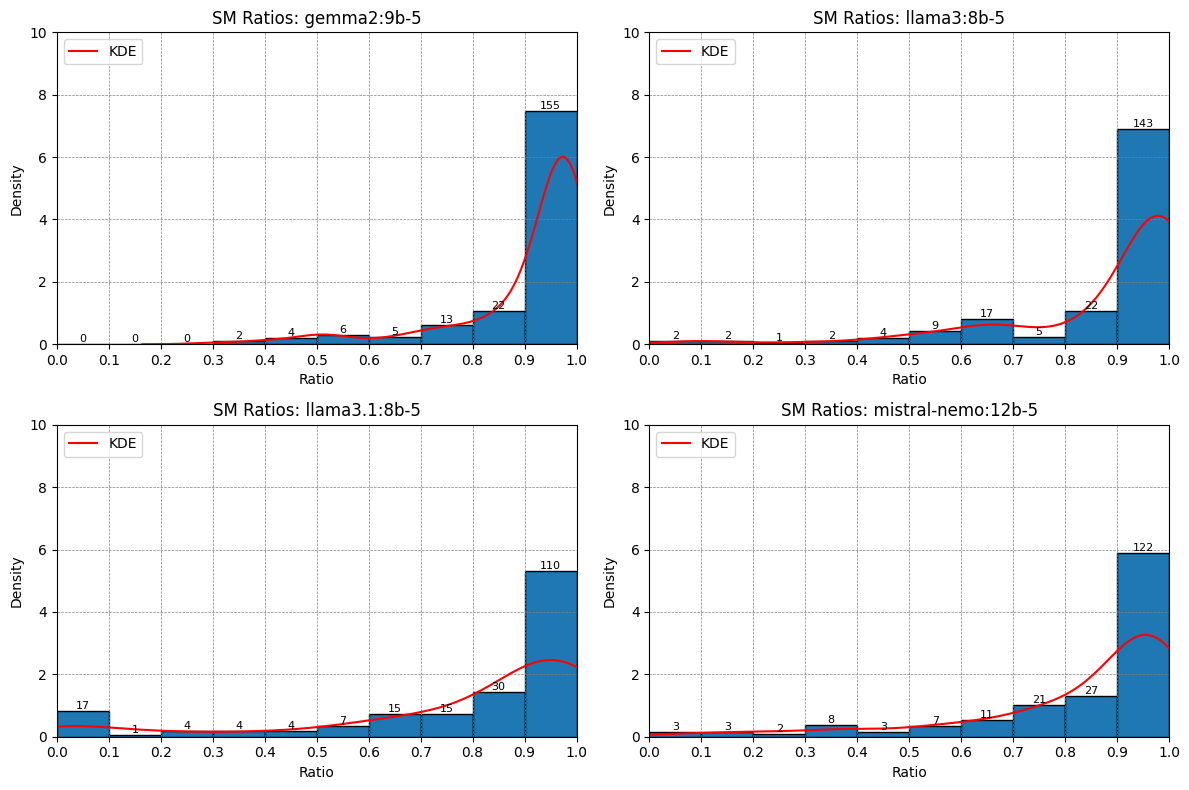

In [29]:
fig, ax = multi_histogram(res, "sm_similarity_ratios", "SM Ratios", "upper left")

#### Levenshtein Distance Ratios

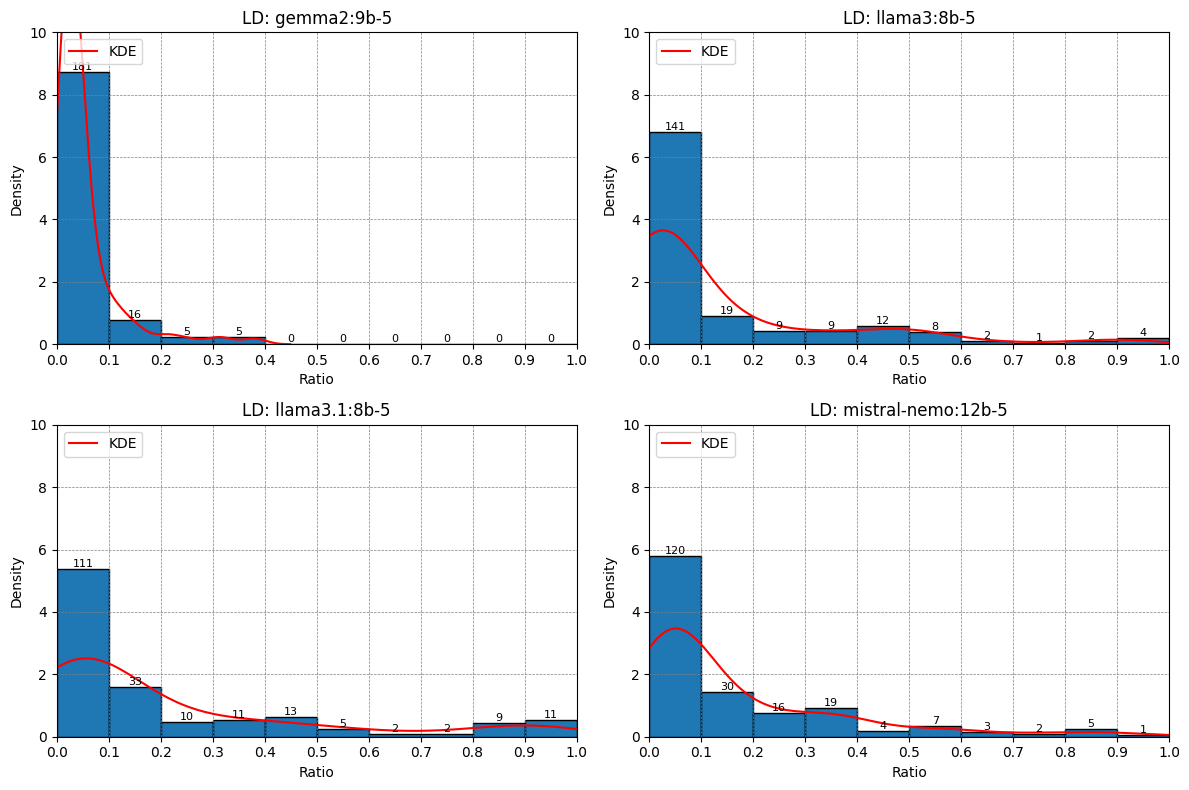

In [30]:
fig, ax = multi_histogram(res, "levenshtein_distance_ratios", "LD", "upper left")

### LanguageTool Metrics

#### Spell Check

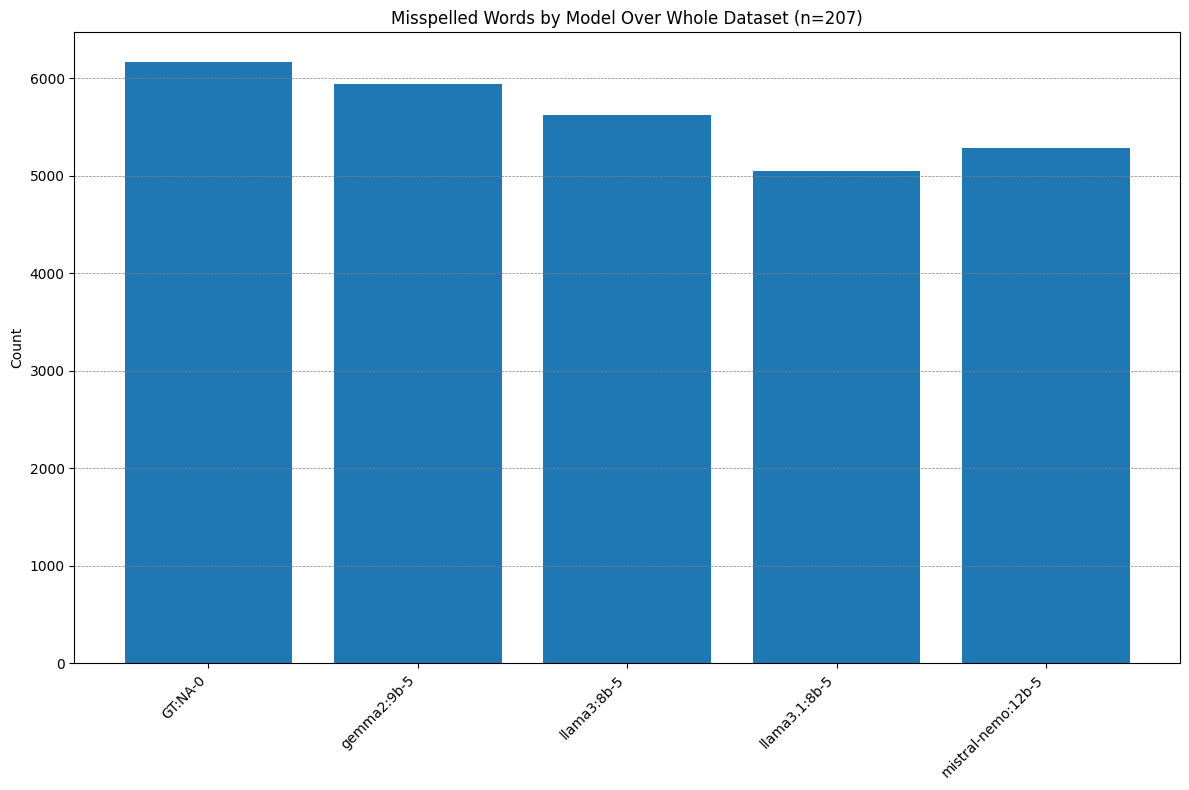

In [31]:
fig, ax = multi_bar_graph(gt_res + res, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

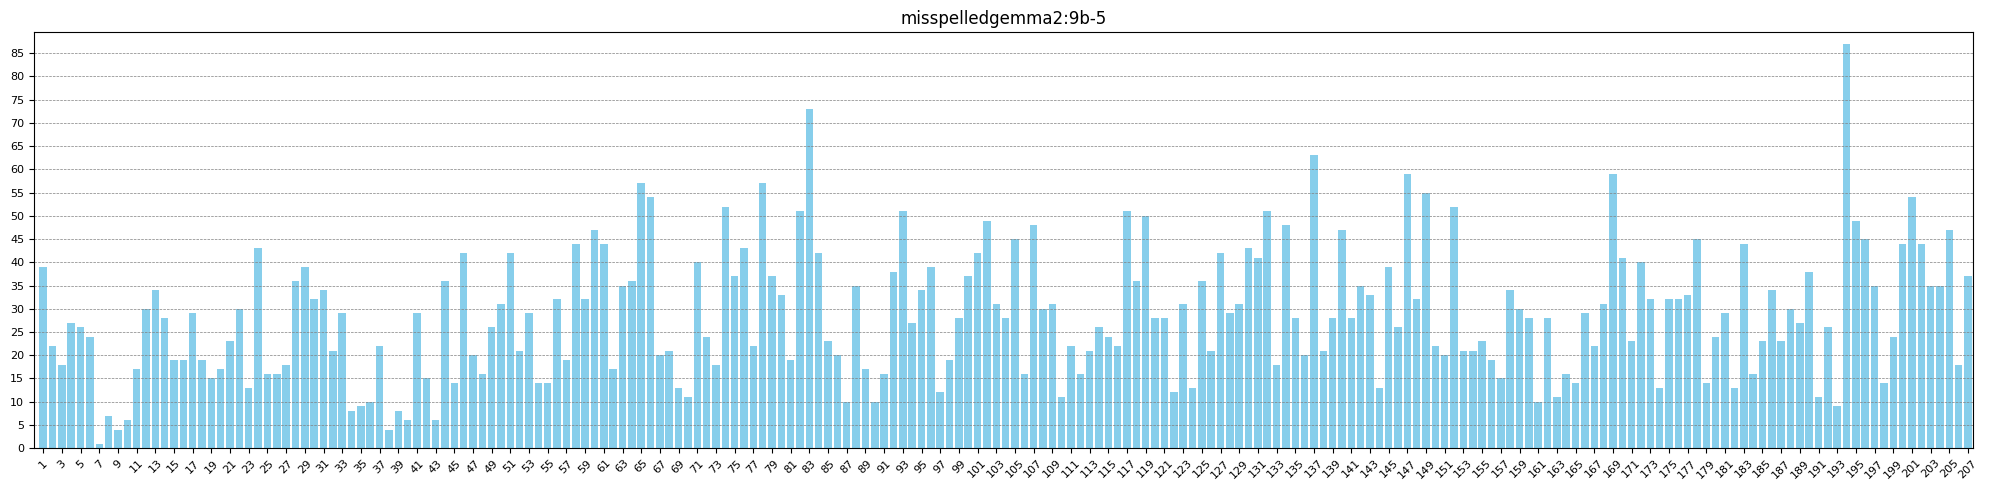

In [32]:
fig, ax = multi_bar_model_graph(res[0], "misspelled", 5)

#### Grammar Check

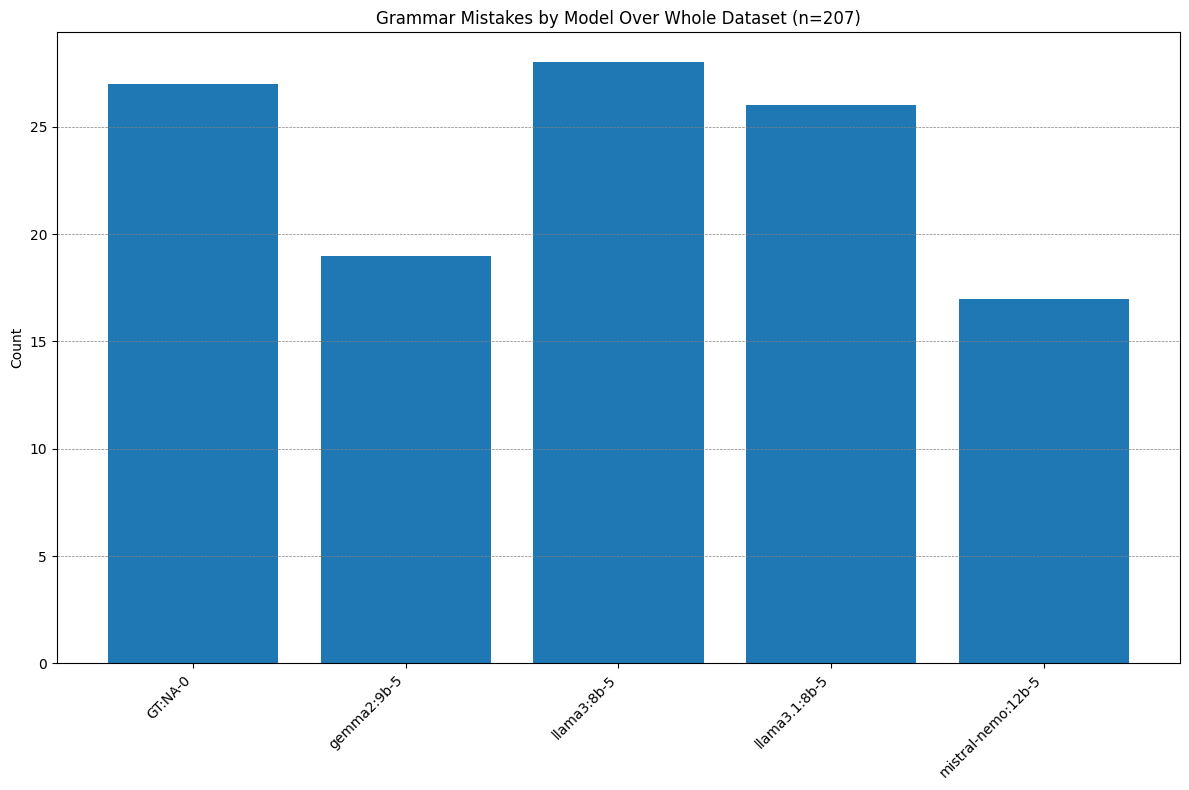

In [33]:
fig, ax = multi_bar_graph(gt_res + res, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

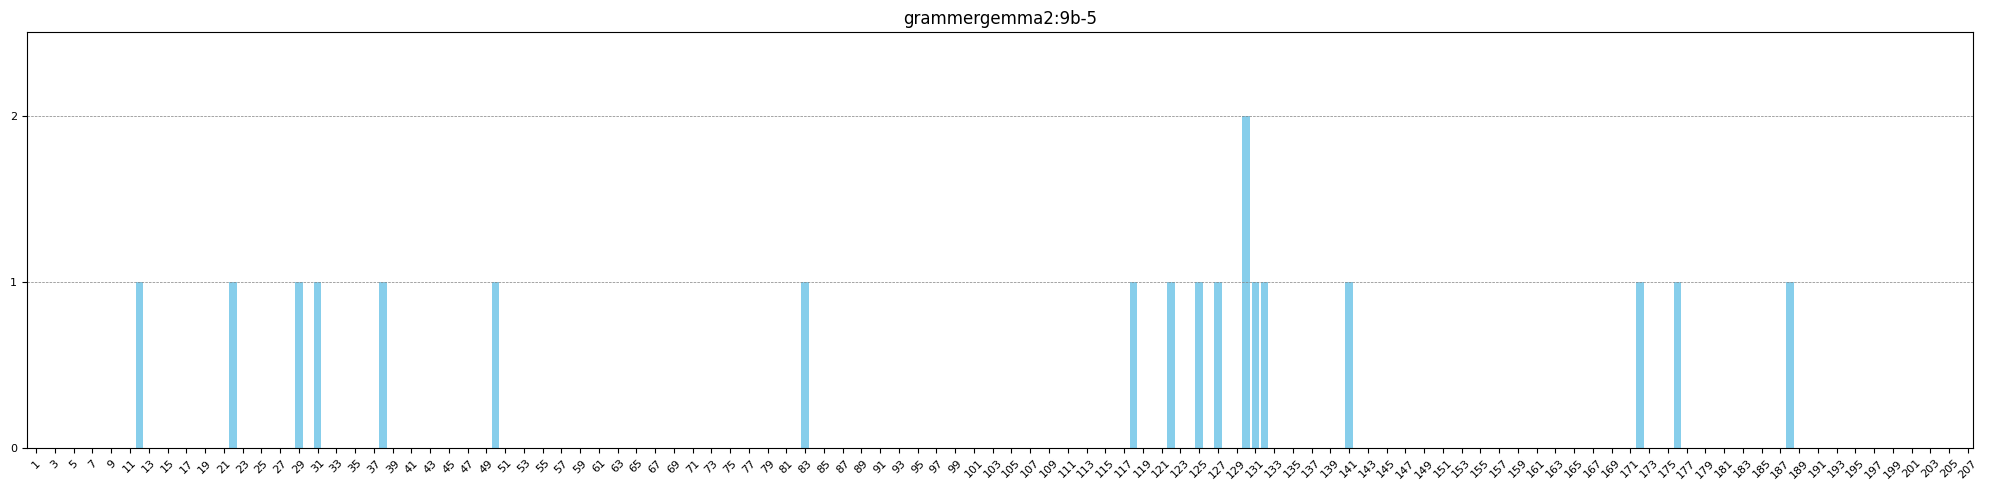

In [34]:
fig, ax = multi_bar_model_graph(res[0], "grammer", 1)

### Semantics Metrics

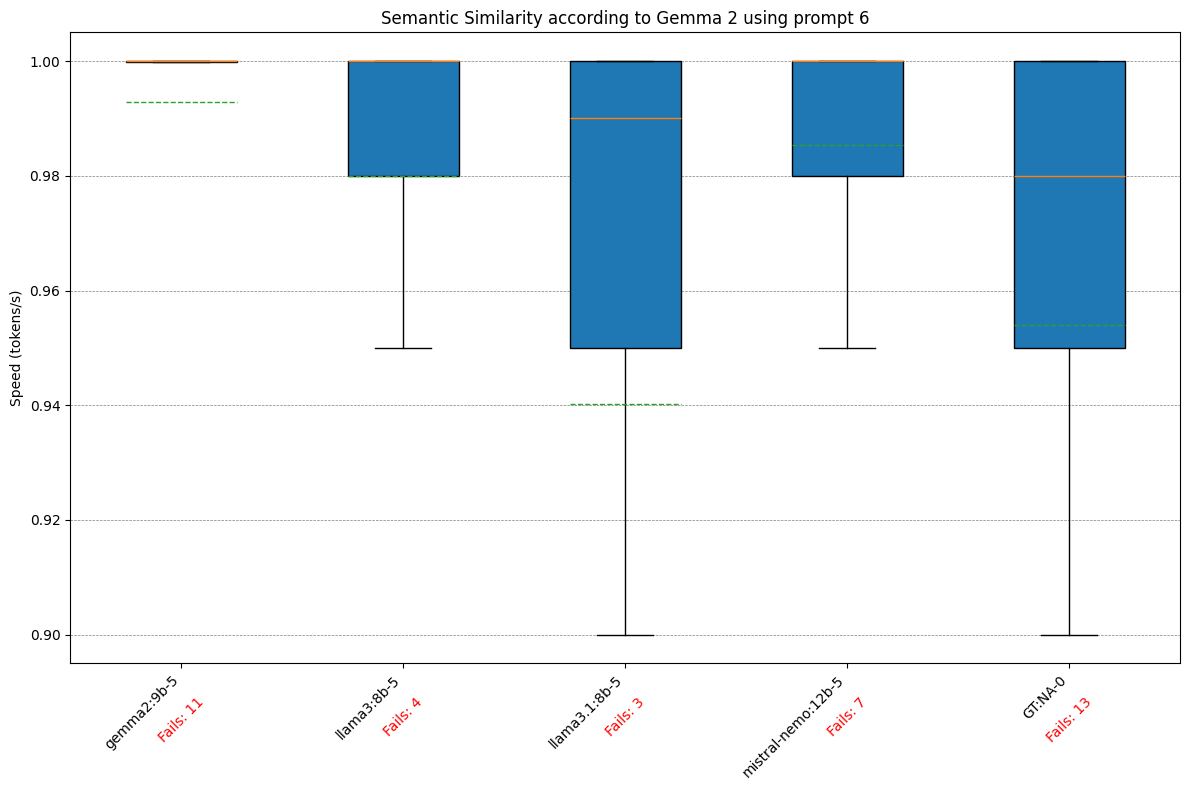

In [35]:
fig, ax = semantic_box_plot(res + gt_res)

You are an evaluation tool whose task is to evaluate if 2 medical reports are semantically different, you will receive 2 reports written in German, your task is to evaluate their semantic similarity by a rating between 0 and 1, where 1 means that the semantics are identical, respond only with the rating and nothing else.

### Violin Plot

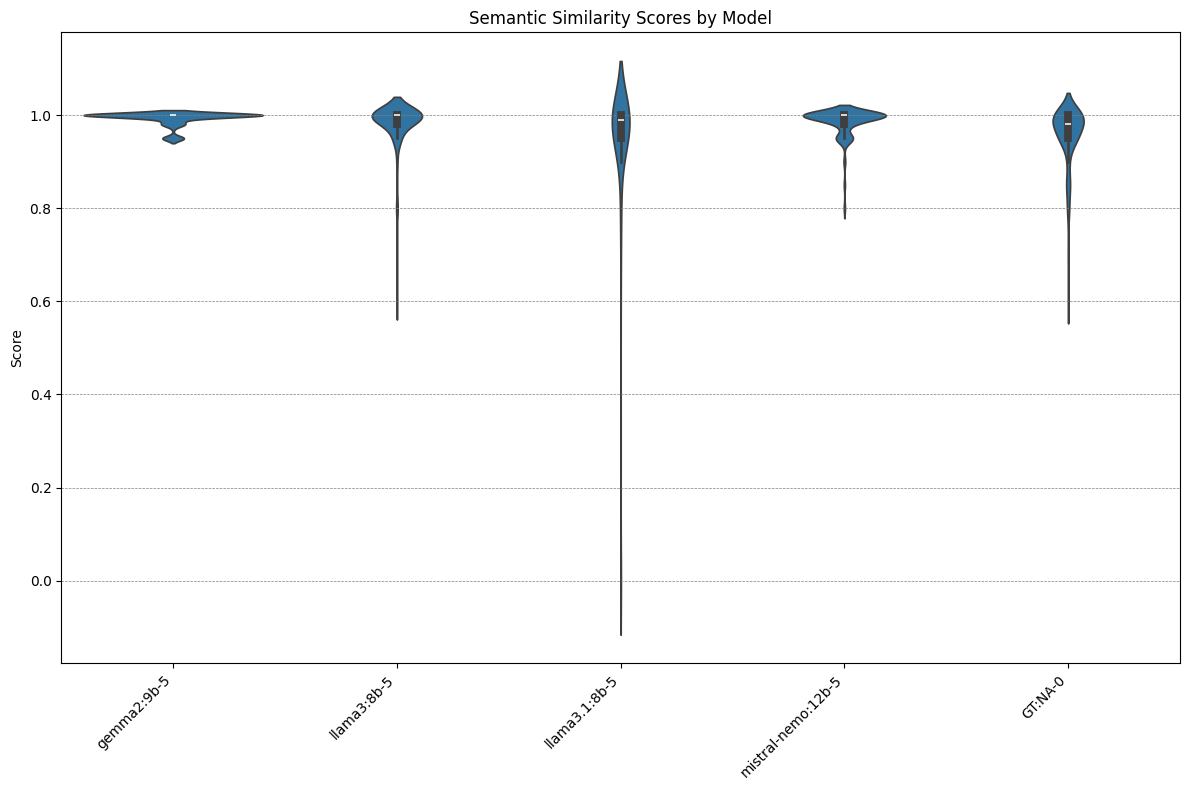

In [36]:
fig, ax = violin_plot(res + gt_res)